# Data Sets from the Literature

The following data sets were obtained from the literature.

## Solvolysis in water/solvent mixture

Data for the solvolysis of benzyl chloride were obtained from..

"Sur un Parallélisme Entre la Mobilité de L'hydrogène du Noyau Benzénique et Celle du Chlore de la Chaîne Latérale" S.C.J. Olivier, *Recl. Trav. Chim. Pays-Bas*, **1930**, *49*, 697-704. https://doi.org/10.1002/recl.19300490803

Rates of hydrolysis are reported for substituted benzyl chlorides in the following conditions.

1. 48\% ethanol, 52\% water, $30 ^\circ C$
2. 48\% ethanol, 52\% water, $83 ^\circ C$
3. 50\% Acetone, 50\% water, $30 ^\circ C$
4. 50\% Acetone, 50\% water, $60 ^\circ C$


**Note:** 
- No acid or base added.  
- Rate constants are first-order rate of in [BzCl] and reported in /$10^{-3} min^{-1}$.

### Cleaning Data Set

the code below will extract and clean the data from the database for use in  this analysis.

In [1]:
####################################################
### Import Libraries and set up global variables ###
####################################################

# Install packages only if needed
# Coogle Colab does not include every Python package
#   
try:                  # if the package exists import it, otherwise install it
    import lmfit
except ImportError:
    !pip -q install lmfit
    import lmfit

try:
    import uncertainties
except ImportError:
    !pip -q install uncertainties
    import uncertainties

# Standard imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
from scipy.stats import linregress
from scipy.optimize import curve_fit

import uncertainties as un
from uncertainties import unumpy as unp

from matplotlib.ticker import FormatStrFormatter
from scipy.stats import t

from pathlib import Path

Path("plots").mkdir(exist_ok=True)
#Path("data").mkdir(exist_ok=True)

try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

#if IN_COLAB and not Path("data/3c.csv").exists():
#    !wget -q -O data/3c.csv https://raw.githubusercontent.com/blinkletter/Chem4410Webbook/main/book/notebooks/M11_Plot_Recommendations/3c.csv

if IN_COLAB and not Path("tufte.mplstyle").exists():
    !wget -q https://raw.githubusercontent.com/blinkletter/Chem4410Webbook/main/book/styles/tufte.mplstyle
if IN_COLAB and not Path("data").exists():
    !wget -q https://raw.github.com/blinkletter/Chem4410Webbook/main/book/notebooks/M12_Handout_Comments/data.zip
    !unzip -q data.zip

github_location_LFER_tables = "https://raw.githubusercontent.com/blinkletter/LFER-QSAR/main/data/"

plt.rcdefaults()

#################################################################
### Global Variable                                           ###
#################################################################

sigmatype = "sigma"          # sigmatype can be one of ["sigma", "s_plus", "s_minus"]


#################################################################
### a function to fill in sigma for empty spaces in s+ and s- ###
#################################################################
def fill_sigma(df):     
    for z in df.index:
        if np.isnan(df.loc[z,"s_plus"]):
            df.loc[z,"s_plus"] = df.loc[z,"sigma"]
        if np.isnan(df["s_minus"][z]):
            df.loc[z,"s_minus"] = df.loc[z,"sigma"]
    return(df)

def Report(comment, result):
    print(comment)
    print(f"slope = {result.slope:-.3f} +/- {result.stderr:.3f}")
    print(f"intercept = {result.intercept:-.3f} +/- {result.intercept_stderr:.3f}")
    print(f"rsq = {(result.rvalue)**2:-.3}")
    print(f"p = {(result.pvalue):-.3}")
    print("")


################################################################################
### Read data set. The fields are separated by commas; comments are enabled  ###
################################################################################

Data_Set = "data/Table_5_Data.csv"

Filename = Data_Set

df1 = pd.read_csv(Filename,
                 delimiter = ",", 
                 skipinitialspace=True, 
                 index_col="Substituent", 
                 comment = "#") 


display(df1)

,k_EtOH_30,k_EtOH_83,k_Acetone_30,k_Acetone_60
Substituent,,,,
H,0.11100,15.50,0.02250,0.460
p-CH3,1.04000,164.00,0.17300,4.000
o-CH3,0.55000,75.00,0.09800,1.890
m-CH3,0.14400,21.60,0.02780,0.550
p-Cl,0.05200,9.60,0.01260,0.268
o-Cl,NaN,5.50,0.00610,0.137
m-Cl,0.01520,3.68,0.00399,0.093
p-Br,0.04570,7.80,0.01100,0.234
o-Br,0.02360,4.44,0.00550,0.129


## Hammett Parameters from A. Williams
This table presents the Hammett $\sigma$ LFER values collected values presented in the collection curated by A. Williams in his book, “Free Energy Relationships in Organic and Bio-organic Chemistry”, *The Royal Society of Chemistry, Cambridge*, **2003**, pp 258-277. https://doi.org/10.1039/9781847550927.

 The data series are as follows:
 
- **Substituent**
     - The code of the substituent and the **index series**. Hopefully we will use a unique code for each substituent that will apply across all these data tables. Students should use data cleaning methods to track down duplicate data and mismatched codes.
- **sigma**
    - The Hammett $\sigma$ value
- **s_plus**
    - The Brown-Okamoto $\sigma_p^+$ value
- **s_minus**
    - The Brown-Okamoto $\sigma_p^-$ value
- **Page**
    - The page number in book. This is included to enable faster checking of the data by other students (all errors are intentional - to see if they are paying attention.)
    
**Note:** You may also use the Hansch data set available from the GitHub page.

### Cleaning Data Set

the code below will extract and clean the data from the database for use in  this analysis.

In [2]:
################################################################################
### Read data set. The fields are separated by commas; comments are enabled  ###
################################################################################

LFER_Data = "LFER_HanschLeoTaft.csv"   # Choose which set of Hammett parameters you prefer
#LFER_Data = "LFER_Williams.csv"

Filename = github_location_LFER_tables + LFER_Data

df2 = pd.read_csv(Filename, 
                 delimiter = ",", 
                 skipinitialspace=True, 
                 index_col="Substituent", 
                 comment = "#") 
#display(df)

########################################################
### Fill across sigma values and select substituents ###
########################################################

df2 = fill_sigma(df2)
#display(df2)

###############################
### Remove unneeded columns ###
###############################
 
df2.drop(labels = ["TABLE V", "TABLE I"],    #Trim "LFER_HanschLeoTaft.csv" data
#df2.drop(labels = ["Page"],                   #Trim "LFER_Williams.csv"" data
        axis = 1,
        inplace = True)
#print(df2)
#df2.sort_values(by=['sigma'], inplace=True)
#display(df2)

## Combine Data Sets

Both data sets are indexed by "Substituent". The code below will combine the two data sets according to "Substituent" and take the intersection of the sets.

In [3]:
df = pd.concat([df2, df1], axis=1, join="inner")
display(df.head())

,sigma,s_plus,s_minus,sigma_I,sigma_n,sigma_star,F,R,R+,R-,k_EtOH_30,k_EtOH_83,k_Acetone_30,k_Acetone_60
Substituent,,,,,,,,,,,,,,
m-Br,0.39,0.39,0.39,NaN,NaN,NaN,NaN,0.00,0.00,0.00,0.0147,3.34,0.00390,0.093
p-Br,0.23,0.15,0.25,0.47,0.230,1.0,0.45,-0.22,-0.30,-0.20,0.0457,7.80,0.01100,0.234
m-CH3,-0.07,-0.07,-0.07,NaN,NaN,NaN,NaN,0.00,0.00,0.00,0.1440,21.60,0.02780,0.550
p-CH3,-0.17,-0.31,-0.17,-0.01,-0.129,-0.1,0.01,-0.18,-0.32,-0.18,1.0400,164.00,0.17300,4.000
m-Cl,0.37,0.37,0.37,NaN,NaN,NaN,NaN,0.00,0.00,0.00,0.0152,3.68,0.00399,0.093


## Calculations

The rates are reported in units of $10^{-3} min^{-1}$.  They will be converted to $min^{-1}$ by multiplying the values by $10^{-3}$. Then the log values will be calculated for the log-log Hammett plots.

See the code below.

In [4]:

df["k_EtOH_30"] = df["k_EtOH_30"]*(10**(-3))
df["k_EtOH_83"] = df["k_EtOH_83"]*(10**(-3))
df["k_Acetone_30"] = df["k_Acetone_30"]*(10**(-3))
df["k_Acetone_60"] = df["k_Acetone_60"]*(10**(-3))
df["log_k_EtOH_30"] = np.log10(df["k_EtOH_30"])
df["log_k_EtOH_83"] = np.log10(df["k_EtOH_83"])
df["log_k_Acetone_30"] = np.log10(df["k_Acetone_30"])
df["log_k_Acetone_60"] = np.log10(df["k_Acetone_60"])
display(df.head())

#df.drop(labels = ["p-CH3"], axis = 0, inplace = True)

,sigma,s_plus,s_minus,sigma_I,sigma_n,sigma_star,F,R,R+,R-,k_EtOH_30,k_EtOH_83,k_Acetone_30,k_Acetone_60,log_k_EtOH_30,log_k_EtOH_83,log_k_Acetone_30,log_k_Acetone_60
Substituent,,,,,,,,,,,,,,,,,,
m-Br,0.39,0.39,0.39,NaN,NaN,NaN,NaN,0.00,0.00,0.00,0.000015,0.00334,0.000004,0.000093,-4.832683,-2.476254,-5.408935,-4.031517
p-Br,0.23,0.15,0.25,0.47,0.230,1.0,0.45,-0.22,-0.30,-0.20,0.000046,0.00780,0.000011,0.000234,-4.340084,-2.107905,-4.958607,-3.630784
m-CH3,-0.07,-0.07,-0.07,NaN,NaN,NaN,NaN,0.00,0.00,0.00,0.000144,0.02160,0.000028,0.000550,-3.841638,-1.665546,-4.555955,-3.259637
p-CH3,-0.17,-0.31,-0.17,-0.01,-0.129,-0.1,0.01,-0.18,-0.32,-0.18,0.001040,0.16400,0.000173,0.004000,-2.982967,-0.785156,-3.761954,-2.397940
m-Cl,0.37,0.37,0.37,NaN,NaN,NaN,NaN,0.00,0.00,0.00,0.000015,0.00368,0.000004,0.000093,-4.818156,-2.434152,-5.399027,-4.031517


Closed circles
48% EtOH, 30 deg
slope = -2.146 +/- 0.247
intercept = -3.848 +/- 0.097
rsq = 0.893
p = 1.15e-05

Open circles
48% EtOH, 83 deg
slope = -1.907 +/- 0.245
intercept = -1.637 +/- 0.096
rsq = 0.871
p = 2.73e-05

Closed squares
50% Acetone, 30 deg
slope = -1.791 +/- 0.245
intercept = -4.549 +/- 0.096
rsq = 0.856
p = 4.47e-05

Open squares
50% Acetone, 60 deg
slope = -1.730 +/- 0.256
intercept = -3.220 +/- 0.100
rsq = 0.836
p = 8.21e-05



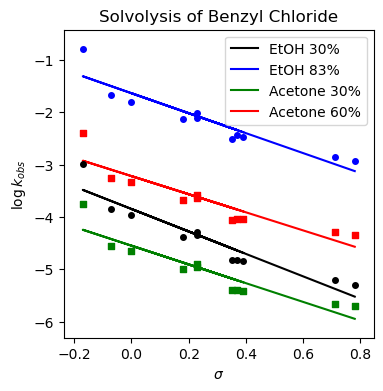

scipy.stats._stats_py.LinregressResult

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
from scipy.stats import linregress

sigmatype = "sigma"       # sigmatype can be one of ["sigma", "s_plus", "s_minus"]

#####################################################################
### Create plot and set up some styling 
#####################################################################

plt.rcdefaults()          # reset the plot parameters to the default values, in case they were changed by a previous plot

sigma = sigmatype 

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(4,4))  
ax.margins(x=.07, y=.07, tight=True)


if sigmatype == "s_plus":
    x_label = r"$\sigma^+$"
elif sigmatype == "s_minus":
    x_label = r"$\sigma^-$"
elif sigmatype == "sigma":
    x_label = r"$\sigma$"
else:
    x_label = "ERROR"

ax.set(
          title="Solvolysis of Benzyl Chloride",       
          ylabel=r"$\log{k_{obs}}$", 
          xlabel=x_label,                
#          xlim=[-.9,.9],                  
#          ylim=[-3.7,-2.7]
         )


##############################
x = df[sigma]
y = df["log_k_EtOH_30"]

linfit = linregress(x,y)
fity = linfit.slope * x + linfit.intercept
ax.plot(x, fity, color='black', zorder=1, label="EtOH 30%")
ax.scatter(x,y, s=16, color="black", marker='o', zorder=3)

print("Closed circles")
Report("48% EtOH, 30 deg", linfit)

##############################
x = df[sigma]
y = df["log_k_EtOH_83"]

linfit = linregress(x,y)
fity = linfit.slope * x + linfit.intercept
ax.plot(x, fity, color='blue', zorder=1, label="EtOH 83%")
ax.scatter(x,y, s=16, color="blue", marker='o', zorder=3)

print("Open circles")
Report("48% EtOH, 83 deg", linfit)

##############################
x = df[sigma]
y = df["log_k_Acetone_30"]

linfit = linregress(x,y)
fity = linfit.slope * x + linfit.intercept
ax.plot(x, fity, color='green', zorder=1, label="Acetone 30%")
ax.scatter(x,y, s=16, color="green", marker='s', zorder=3)

print("Closed squares")
Report("50% Acetone, 30 deg", linfit)

##############################
x = df[sigma]
y = df["log_k_Acetone_60"]

linfit = linregress(x,y)
fity = linfit.slope * x + linfit.intercept
ax.plot(x, fity, color='red', zorder=1, label="Acetone 60%")
ax.scatter(x,y, s=16, color="red", marker='s',  zorder=3)

print("Open squares")
Report("50% Acetone, 60 deg", linfit)
plt.legend()
plt.show()
fig.savefig("plots/plot5.pdf") 

type(linfit)